# Python for Finance
## Portfolio Optimisation and Value-at-Risk: A Seven-Asset USD Portfolio

<img style="border:0px solid grey;" src="http://grid1.stalwart.it/up/SBS.jpg" alt="Surrey Business School" align="center" border="0">

**Course:** MANM525 -- Financial Modelling
**Author:** Kunal Chaudhari
**Semester:** February 2025

## 1. Introduction

This project builds and risk-manages a diversified, USD-denominated portfolio using real Bloomberg Terminal market data across seven instruments: four single stocks, an international equity index, a bond ETF and a risk-free cash leg. The goals are:

1. **Construct** a maximum-Sharpe-ratio portfolio using Modern Portfolio Theory (Markowitz mean-variance optimisation), with no short-selling.
2. **Quantify downside risk** with a one-month, 95% Value-at-Risk (VaR), using both a parametric Normal approach and a GARCH(1,1) conditional-volatility approach.

Exchange-rate risk is handled explicitly: the DAX leg is quoted in EUR and is converted into USD returns before it enters the optimisation, so every return series in the model is expressed in a common currency.

### Assets Included
| Ticker | Asset | Role |
|---|---|---|
| GOOGL | Alphabet Inc. | Growth / technology exposure |
| AMZN | Amazon.com Inc. | Growth / technology exposure |
| TSLA | Tesla Inc. | High-volatility growth opportunity |
| GS | Goldman Sachs Group | Financials sector diversification |
| DAX (Total Return) | German equity index, EUR $\to$ USD | Regional diversification & FX risk |
| BNDX | USD-denominated bond ETF | Interest-rate sensitivity / ballast |
| RF | USD savings account, 3.5% p.a. | Stability & liquidity buffer |

This combination lets the model explore practical multi-asset-class diversification and then put a number on the portfolio's tail risk.

## 2. Data Sourcing & Cleaning Methodology

All price series were exported from a **Bloomberg Terminal** using the `PX_LAST` field (the DAX leg additionally carries `TOT_RETURN_INDEX_GROSS_DVDS`, Bloomberg's total-return index field, which is used here so that the DAX leg reflects reinvested dividends rather than just price appreciation). Six of the seven series (GOOGL, AMZN, TSLA, GS, DAX, EURUSD) were pulled at **weekly (Friday) frequency** from 10-Apr-2020 to 04-Apr-2025 (~5 years). The BNDX bond ETF was only available at **daily** frequency over a shorter window (10-Apr-2024 to 10-Apr-2025); it is resampled to weekly (last observation each Friday) below so that it lines up with the other six series on a common weekly calendar.

**Practical consequence:** because BNDX is the shortest series, it caps the usable overlapping sample at roughly one year (~52 weekly observations) even though the other six assets have five years of history available. This is flagged explicitly as a limitation in Section 8 -- pulling a full five-year BNDX history from Bloomberg would be the natural next step to strengthen the statistical power of both the optimisation and the GARCH fit.

Each raw Bloomberg export carries six metadata rows (`Security`, `Start Date`, `End Date`, `Period`, `Currency`, a blank row) before the actual `Date, PX_LAST, ...` header, so the loader below locates that header programmatically rather than assuming a fixed number of rows to skip.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import norm
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 100


def load_bloomberg_csv(fname, price_col='PX_LAST'):
    '''Read a raw Bloomberg-export CSV: locate the 'Date,...' header row
    (skipping the Security/Start Date/... metadata block), parse UK-format
    dates, drop bad/duplicate rows, and return a clean price Series.'''
    with open(fname, encoding='utf-8-sig') as f:
        lines = f.readlines()
    header_idx = next(i for i, l in enumerate(lines) if l.startswith('Date,'))
    df = pd.read_csv(fname, skiprows=header_idx)
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
    df = df.dropna(subset=['Date']).drop_duplicates('Date').sort_values('Date')
    s = pd.to_numeric(df[price_col], errors='coerce')
    s.index = df['Date']
    return s.dropna()


# 1) Define file mapping (ticker -> (filename, Bloomberg field to use)
DATA_DIR = 'data/'
FILES = {
    'GOOGL':  (DATA_DIR + 'Google stock.csv', 'PX_LAST'),
    'AMZN':   (DATA_DIR + 'Amazon stock.csv', 'PX_LAST'),
    'TSLA':   (DATA_DIR + 'Tesla stock.csv', 'PX_LAST'),
    'GS':     (DATA_DIR + 'Goldman stock.csv', 'PX_LAST'),
    'DAX':    (DATA_DIR + 'Dax Total return.csv', 'TOT_RETURN_INDEX_GROSS_DVDS'),
    'EURUSD': (DATA_DIR + 'Conversion rates (dax).csv', 'PX_LAST'),
    'BNDX':   (DATA_DIR + 'BNDX stock.csv', 'PX_LAST'),
}

# 2) Load each series
series = {tkr: load_bloomberg_csv(fname, col) for tkr, (fname, col) in FILES.items()}
for tkr, s in series.items():
    print(f"{tkr:7s} raw obs={len(s):4d}  range={s.index.min().date()} -> {s.index.max().date()}  freq={pd.infer_freq(s.index) or 'irregular'}")

# 3) BNDX is daily -> resample to weekly (Friday) to match the other six series
series['BNDX'] = series['BNDX'].resample('W-FRI').last().dropna()
print(f"\nBNDX resampled to weekly: {len(series['BNDX'])} observations")

# 4) Align on common dates and build the price panel
common = sorted(set.intersection(*(set(s.index) for s in series.values())))
prices = pd.DataFrame({t: series[t].loc[common] for t in series}, index=common)

# 5) Data integrity checks
print("\nMissing values per column:\n", prices.isnull().sum())
print("Duplicate dates in index:", prices.index.duplicated().sum())
print(f"\nFinal aligned panel: {prices.shape[0]} weekly observations "
      f"({prices.shape[0]/52:.2f} years), {prices.shape[1]} series")
print(f"Date range: {prices.index.min().date()} -> {prices.index.max().date()}")
prices.head()

GOOGL   raw obs= 261  range=2020-04-10 -> 2025-04-04  freq=W-FRI
AMZN    raw obs= 261  range=2020-04-10 -> 2025-04-04  freq=W-FRI
TSLA    raw obs= 261  range=2020-04-10 -> 2025-04-04  freq=W-FRI
GS      raw obs= 261  range=2020-04-10 -> 2025-04-04  freq=W-FRI
DAX     raw obs= 261  range=2020-04-10 -> 2025-04-04  freq=W-FRI
EURUSD  raw obs= 261  range=2020-04-10 -> 2025-04-04  freq=W-FRI
BNDX    raw obs= 252  range=2024-04-10 -> 2025-04-10  freq=irregular

BNDX resampled to weekly: 53 observations

Missing values per column:
 GOOGL     0
AMZN      0
TSLA      0
GS        0
DAX       0
EURUSD    0
BNDX      0
dtype: int64
Duplicate dates in index: 0

Final aligned panel: 52 weekly observations (1.00 years), 7 series
Date range: 2024-04-12 -> 2025-04-04


,GOOGL,AMZN,TSLA,GS,DAX,EURUSD,BNDX
2024-04-12,157.73,186.13,171.05,389.49,17930.32,1.0643,48.88
2024-04-19,154.09,174.63,147.05,404.00,17737.36,1.0656,48.59
2024-04-26,171.95,179.62,168.29,427.57,18161.01,1.0693,48.44
2024-05-03,167.24,186.21,181.19,438.18,18001.60,1.0761,48.68
2024-05-10,168.65,187.48,168.47,454.73,18772.85,1.0771,48.66


## 3. Returns, FX Conversion & the Risk-Free Leg

Weekly simple returns are computed from the price panel. The DAX leg is quoted in EUR, so its USD return is built by compounding the EUR return with the EUR/USD return:

$$r_{DAX}^{USD} = (1 + r_{DAX}^{EUR})(1 + r_{EURUSD}) - 1$$

The risk-free leg is a USD savings account paying **3.5% p.a.** Because every other series here is sampled **weekly** (52 periods/year), the risk-free rate must be converted to an equivalent *weekly* rate -- not a daily one -- so that it is on the same footing as the rest of the model:

$$r_f^{weekly} = (1 + 0.035)^{1/52} - 1$$

In [2]:
# Weekly risk-free rate (matches the 52-week sampling frequency of the price data)
RF_ANNUAL = 0.035
PERIODS_PER_YEAR = 52  # weekly data -- used consistently everywhere below

rf_weekly = (1 + RF_ANNUAL) ** (1 / PERIODS_PER_YEAR) - 1
rf_series = pd.Series(rf_weekly, index=prices.index, name='RF')
print(f"Weekly risk-free return: {rf_weekly:.6f} ({rf_weekly*100:.4f}%)")


def compute_returns(price_df, rf=None):
    '''Weekly simple returns; converts the DAX leg to USD and (optionally)
    appends a constant weekly risk-free return series.'''
    r = price_df.pct_change().dropna()
    r['DAX_USD'] = (1 + r['DAX']) * (1 + r['EURUSD']) - 1
    r = r.drop(columns=['DAX', 'EURUSD'])
    if rf is not None:
        r['RF'] = rf.reindex(r.index)
    return r


rets = compute_returns(prices, rf_series)

summary = rets.describe().T[['mean', 'std']]
summary.columns = ['Avg Weekly Return', 'Weekly Volatility']
summary

Weekly risk-free return: 0.000662 (0.0662%)


,Avg Weekly Return,Weekly Volatility
GOOGL,-0.000832,0.038788
AMZN,-0.000871,0.040046
TSLA,0.010655,0.093505
GS,0.004677,0.043972
BNDX,0.000101,0.006502
DAX_USD,0.003679,0.026501
RF,0.000662,0.000000


### Correlation structure

Computed on the return series actually used in the optimisation (i.e. the DAX leg **after** FX conversion to USD, not the raw EUR-denominated leg).

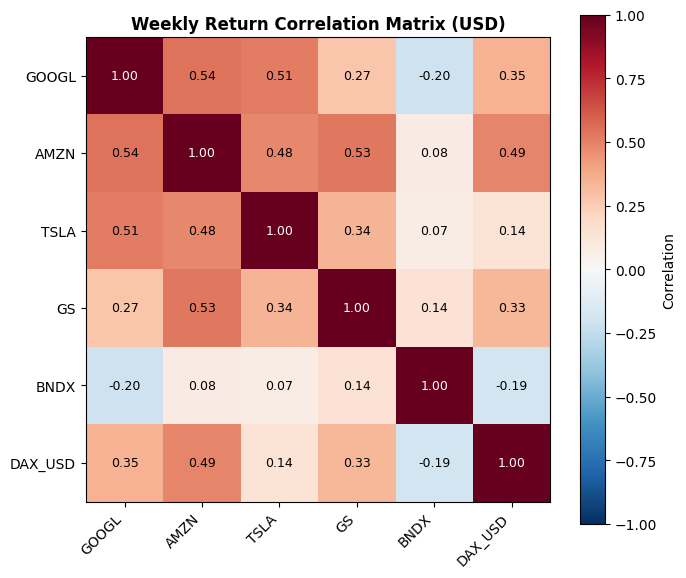

,GOOGL,AMZN,TSLA,GS,BNDX,DAX_USD
GOOGL,1.000,0.540,0.515,0.274,-0.205,0.349
AMZN,0.540,1.000,0.481,0.525,0.081,0.486
TSLA,0.515,0.481,1.000,0.337,0.075,0.138
GS,0.274,0.525,0.337,1.000,0.141,0.332
BNDX,-0.205,0.081,0.075,0.141,1.000,-0.194
DAX_USD,0.349,0.486,0.138,0.332,-0.194,1.000


In [3]:
corr = rets.drop(columns='RF').corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                 color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black', fontsize=9)
fig.colorbar(im, label='Correlation')
ax.set_title('Weekly Return Correlation Matrix (USD)', fontweight='bold')
plt.tight_layout()
plt.show()

corr.round(3)

## 4. Mean-Variance & Sharpe-Ratio Optimisation

Modern Portfolio Theory (Markowitz, 1952) frames portfolio choice as trading off expected return against variance. For a portfolio with $n$ assets, weight vector $\mathbf w$, expected-return vector $\boldsymbol\mu$ and covariance matrix $\Sigma$:

$$E(R_p) = \mathbf w^\top \boldsymbol\mu, \qquad \sigma_p^2 = \mathbf w^\top \Sigma \mathbf w$$

The **tangency portfolio** is the point on the efficient frontier with the highest Sharpe ratio -- the best risk-adjusted return achievable given a risk-free rate $r_f$:

$$\max_{\mathbf w}\;\frac{\mathbf w^\top \boldsymbol\mu - r_f}{\sqrt{\mathbf w^\top \Sigma\, \mathbf w}} \quad\text{s.t.}\quad \sum_i w_i = 1,\; w_i \ge 0$$

Because the risk-free savings account is treated here as one of the seven investable lines (rather than purely a rate in the Sharpe-ratio formula), it is included directly in $\boldsymbol\mu$ and $\Sigma$ alongside the six risky assets: its return series is constant, so it contributes (effectively) zero variance and zero covariance, and the optimiser is free to allocate to it as a stability buffer.

**A critical detail for weekly data:** `PyPortfolioOpt`'s helper functions default to `frequency=252` (calendar/trading-day annualisation), which silently assumes *daily* prices. Since this dataset is weekly, `frequency=52` must be passed explicitly to both `expected_returns.mean_historical_return` and `risk_models.sample_cov` -- otherwise expected returns and volatility are annualised as if there were five times as many observations per year as there actually are, inflating the annual return figure by roughly $252/52 \approx 4.8\times$ and distorting the Sharpe ratio.

In [4]:
from pypfopt import expected_returns, risk_models, EfficientFrontier

# USD price panel used for optimisation: convert DAX to USD, add a synthetic
# RF price path growing at the weekly risk-free rate
prices_usd = prices.copy()
prices_usd['DAX_USD'] = prices_usd['DAX'] * prices_usd['EURUSD']
prices_usd = prices_usd.drop(columns=['DAX', 'EURUSD'])
prices_usd['RF'] = (1 + rf_weekly) ** np.arange(len(prices_usd))

# frequency=52: weekly data, NOT the PyPortfolioOpt default of 252 (daily)
mu = expected_returns.mean_historical_return(prices_usd, frequency=PERIODS_PER_YEAR)
Sigma = risk_models.sample_cov(prices_usd, frequency=PERIODS_PER_YEAR)

print("Annualised expected returns:\n", mu.round(4))

Annualised expected returns:
 GOOGL     -0.0784
AMZN      -0.0828
TSLA       0.4090
GS         0.2133
BNDX       0.0042
DAX_USD    0.1890
RF         0.0350
dtype: float64


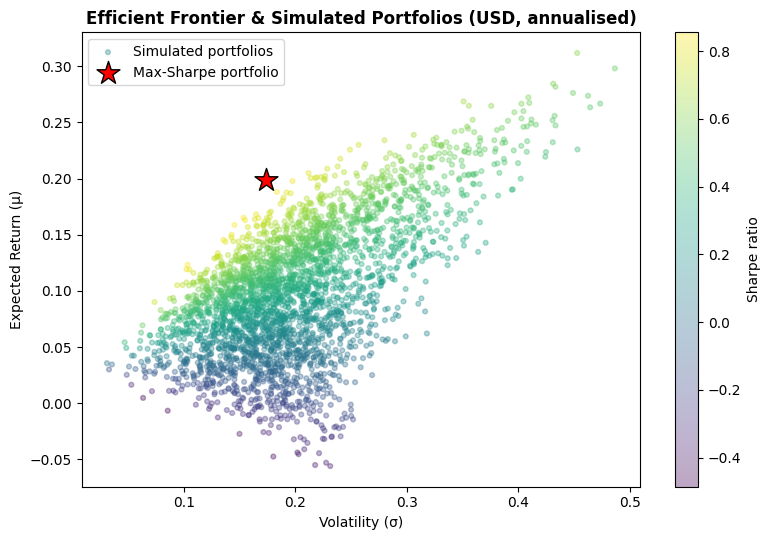

Max-Sharpe portfolio -- Expected annual return: 19.84% | Annual volatility: 17.39% | Sharpe ratio: 0.94


GOOGL      0.00000
AMZN       0.00000
TSLA       0.10755
GS         0.11845
BNDX       0.00000
DAX_USD    0.66271
RF         0.11130
dtype: float64

In [5]:
# Simulate random long-only portfolios to visualise the efficient frontier
np.random.seed(42)
n_sim = 3000
sim_rets, sim_vols = [], []
for _ in range(n_sim):
    w_rand = np.random.dirichlet(np.ones(len(mu)))
    sim_rets.append(w_rand @ mu.values)
    sim_vols.append(np.sqrt(w_rand @ Sigma.values @ w_rand))
sim_rets, sim_vols = np.array(sim_rets), np.array(sim_vols)
sim_sharpe = (sim_rets - RF_ANNUAL) / sim_vols

# Solve for the max-Sharpe (tangency) portfolio
ef = EfficientFrontier(mu, Sigma, weight_bounds=(0, 1))
ef.max_sharpe(risk_free_rate=RF_ANNUAL)
w_series = pd.Series(ef.clean_weights())
ret_ann, vol_ann, sharpe_ann = ef.portfolio_performance(risk_free_rate=RF_ANNUAL, verbose=False)

plt.figure(figsize=(8, 5.5))
sc = plt.scatter(sim_vols, sim_rets, c=sim_sharpe, cmap='viridis', alpha=0.35, s=12, label='Simulated portfolios')
plt.scatter(vol_ann, ret_ann, color='red', marker='*', s=300, edgecolor='black', zorder=5, label='Max-Sharpe portfolio')
plt.colorbar(sc, label='Sharpe ratio')
plt.title('Efficient Frontier & Simulated Portfolios (USD, annualised)', fontweight='bold')
plt.xlabel('Volatility (σ)'); plt.ylabel('Expected Return (μ)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Max-Sharpe portfolio -- Expected annual return: {ret_ann:.2%} | "
      f"Annual volatility: {vol_ann:.2%} | Sharpe ratio: {sharpe_ann:.2f}")
w_series

### Optimal weights

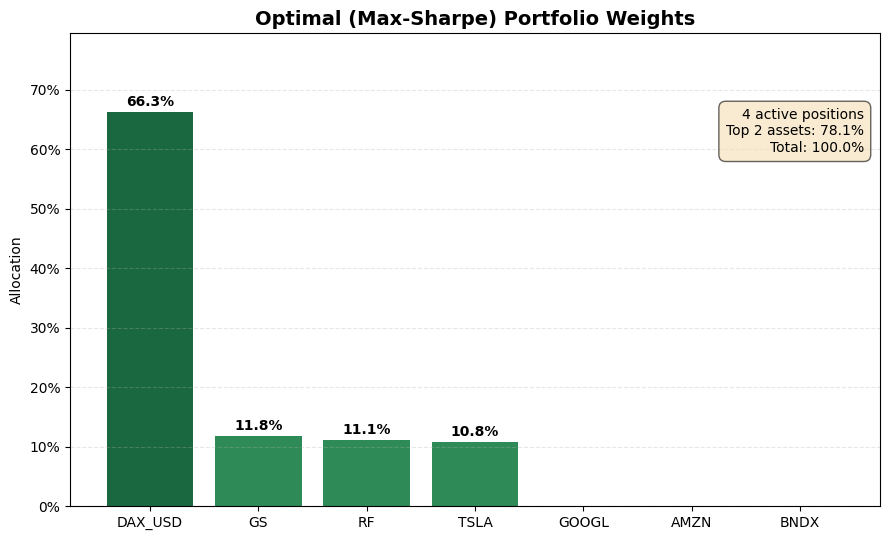

In [6]:
sorted_w = w_series.sort_values(ascending=False)
colors = ['#1A6840' if v > 0.30 else '#2E8B57' if v > 0.10 else '#66CDAA' if v > 0.01 else '#D3D3D3'
          for v in sorted_w.values]

plt.figure(figsize=(9, 5.5))
bars = plt.bar(sorted_w.index, sorted_w.values, color=colors)
for bar in bars:
    h = bar.get_height()
    if h > 0.005:
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.1%}', ha='center', fontweight='bold')
plt.title('Optimal (Max-Sharpe) Portfolio Weights', fontsize=14, fontweight='bold')
plt.ylabel('Allocation'); plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylim(0, max(sorted_w.values) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.3)

active = (sorted_w > 0.001).sum()
plt.annotate(f"{active} active positions\nTop 2 assets: {sorted_w.nlargest(2).sum():.1%}\nTotal: {sorted_w.sum():.1%}",
             xy=(0.98, 0.75), xycoords='axes fraction', ha='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.6))
plt.tight_layout()
plt.show()

### Interpreting the weights

_(see Section 8, "Results & Interpretation", for the numeric readout, which is generated from the live `w_series` above rather than typed in by hand -- so it can never drift out of sync with the optimiser's actual output.)_

## 5. Simulated Portfolio Value Paths

A simple stationary bootstrap: resample the historical weekly returns with replacement and compound them using the optimal weights, to get a feel for the range of outcomes the historical return/volatility profile implies.

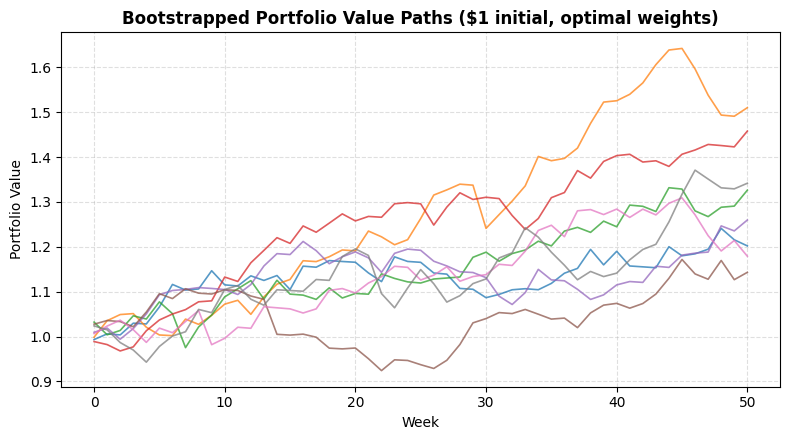

In [7]:
rets_df = prices_usd.drop(columns='RF').pct_change().dropna()
rets_df['RF'] = rf_weekly
w_opt = w_series.reindex(rets_df.columns).values

np.random.seed(7)
T, n_paths = len(rets_df), 8
plt.figure(figsize=(8, 4.5))
for _ in range(n_paths):
    idx = np.random.choice(T, size=T, replace=True)
    port_r_path = rets_df.values[idx] @ w_opt
    plt.plot(np.cumprod(1 + port_r_path), alpha=0.75, lw=1.2)
plt.title('Bootstrapped Portfolio Value Paths ($1 initial, optimal weights)', fontweight='bold')
plt.xlabel('Week'); plt.ylabel('Portfolio Value')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Value at Risk: Concept & Methods

Value-at-Risk answers: *"What is the maximum loss we would not expect to exceed, at a given confidence level, over a given horizon?"* For portfolio returns $X$ at confidence $\alpha$:

$$VaR_\alpha = -F^{-1}(1-\alpha)$$

**Normal (parametric) VaR** assumes $X \sim N(\mu, \sigma^2)$:

$$VaR_\alpha = -(\mu + \sigma\,\Phi^{-1}(1-\alpha))$$

Real returns typically show fat tails, skew and volatility clustering, which the Normal assumption misses. **GARCH(1,1)** addresses the volatility-clustering piece by letting variance evolve conditionally on past shocks and past variance:

$$\sigma_t^2 = \omega + \alpha\, r_{t-1}^2 + \beta\, \sigma_{t-1}^2$$

### Getting the horizon right for weekly data

A "1-month" VaR is conventionally scaled by $\sqrt{21}$ -- but that figure is the number of *trading days* in a month, which only makes sense when the underlying returns are daily. This model's returns are **weekly**, so the correct scaling for a one-month (~4-week) horizon is $\sqrt{4}$, not $\sqrt{21}$:

$$\mu_{4} = 4\bar r, \qquad \sigma_4 = \hat\sigma\sqrt4, \qquad VaR_{95\%} = -(\mu_4 + \sigma_4\, z_{0.05})$$

Using $\sqrt{21}$ on weekly data would implicitly price in a 21-*week* (~5-month) horizon while labelling it "1-month" -- overstating the reported VaR by roughly $\sqrt{21/4} \approx 2.3\times$.

In [8]:
# Realised weekly portfolio returns under the optimal weights (real data --
# this feeds both the VaR estimate below and the risk dashboard in Section 7)
w_risky = w_series.drop('RF')
w_rf = w_series['RF']
port_rets = rets[w_risky.index].dot(w_risky) + rets['RF'] * w_rf

HORIZON_WEEKS = 4  # ~1 month, given weekly data

mu_h = port_rets.mean() * HORIZON_WEEKS
sd_h = port_rets.std() * np.sqrt(HORIZON_WEEKS)
VaR95_normal = -(mu_h + sd_h * norm.ppf(0.05))
VaR99_normal = -(mu_h + sd_h * norm.ppf(0.01))

# GARCH(1,1) conditional volatility
from arch import arch_model
garch_res = arch_model(port_rets * 100, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
sigma_last = garch_res.conditional_volatility.iloc[-1] / 100
sigma_h_garch = sigma_last * np.sqrt(HORIZON_WEEKS)
VaR95_garch = -(mu_h + sigma_h_garch * norm.ppf(0.05))

results = pd.DataFrame({
    'Method': ['Normal (historical σ)', 'GARCH(1,1) conditional σ'],
    '1-Month 95% VaR': [f'{VaR95_normal:.2%}', f'{VaR95_garch:.2%}'],
})
print(results.to_string(index=False))
print(f"\n1-Month 99% VaR (Normal): {VaR99_normal:.2%}")
print(f"\nGARCH(1,1) fitted parameters:\n{garch_res.params}")

                  Method 1-Month 95% VaR
   Normal (historical σ)           6.25%
GARCH(1,1) conditional σ           6.17%

1-Month 99% VaR (Normal): 9.53%

GARCH(1,1) fitted parameters:
mu          4.211843e-01
omega       2.870419e+00
alpha[1]    7.239867e-14
beta[1]     4.970749e-01
Name: params, dtype: float64


### A note on the GARCH fit

With only ~51 weekly return observations, the fitted GARCH(1,1) has very little data to separate genuine volatility clustering (the $\alpha$ term) from a simple constant-variance baseline ($\omega$). If $\hat\alpha$ comes out at or near zero, that is the model honestly saying it cannot detect meaningful ARCH effects at this sample size -- not that none exist. That is why the GARCH-based VaR above tracks the Normal-VaR estimate so closely: with $\alpha\approx0$, GARCH(1,1) collapses toward a near-constant-volatility model. **This is a real limitation of the current sample size, not a modelling error**, and a longer BNDX history (matching the other six assets' five-year window) would let GARCH actually earn its keep here.

## 7. Risk Dashboard

Built entirely from the realised portfolio return series (`port_rets`) computed above under the optimal weights -- not a simulated placeholder.

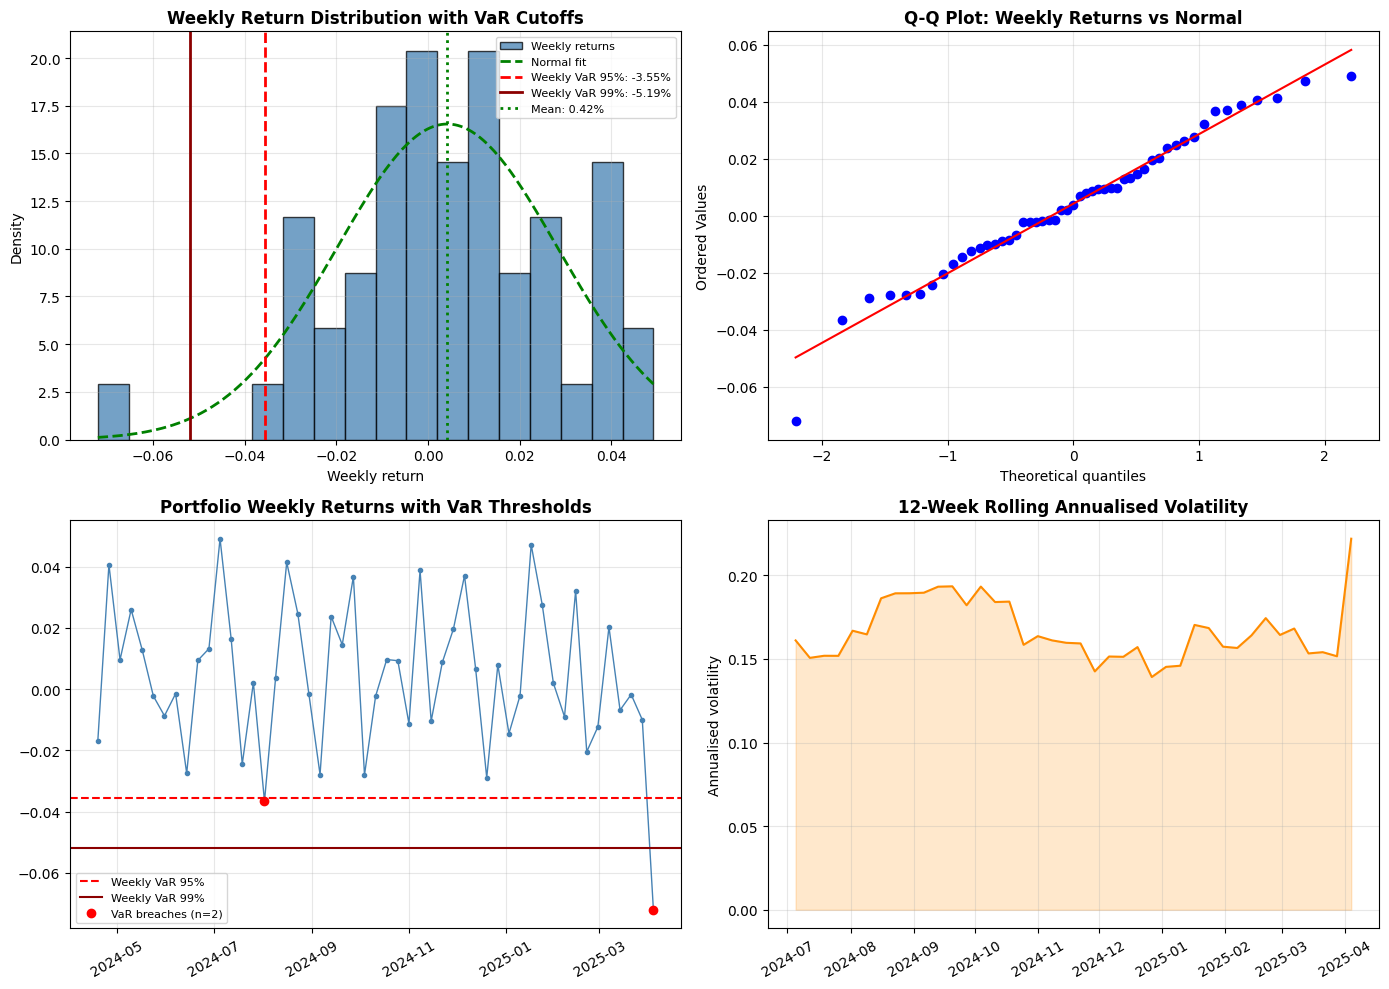

Mean weekly return          0.0042
Weekly volatility           0.0241
Annualised Sharpe ratio     0.9398
Weekly VaR 95%              0.0355
Weekly VaR 99%              0.0519
Weekly CVaR (ES) 95%        0.0458
Weekly CVaR (ES) 99%        0.0720
Max drawdown               -0.1008
Skewness                   -0.3825
Excess kurtosis             0.5659
dtype: str

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (1) Return distribution with VaR cutoffs ---
ax = axes[0, 0]
ax.hist(port_rets, bins=18, density=True, alpha=0.75, color='steelblue', edgecolor='black', label='Weekly returns')
mu_w, sd_w = port_rets.mean(), port_rets.std()
x = np.linspace(port_rets.min(), port_rets.max(), 200)
ax.plot(x, norm.pdf(x, mu_w, sd_w), 'g--', lw=2, label='Normal fit')
VaR95_w = -(mu_w + sd_w * norm.ppf(0.05))
VaR99_w = -(mu_w + sd_w * norm.ppf(0.01))
ax.axvline(-VaR95_w, color='red', ls='--', lw=2, label=f'Weekly VaR 95%: {-VaR95_w:.2%}')
ax.axvline(-VaR99_w, color='darkred', ls='-', lw=2, label=f'Weekly VaR 99%: {-VaR99_w:.2%}')
ax.axvline(mu_w, color='green', ls=':', lw=2, label=f'Mean: {mu_w:.2%}')
ax.set_title('Weekly Return Distribution with VaR Cutoffs', fontweight='bold')
ax.set_xlabel('Weekly return'); ax.set_ylabel('Density'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- (2) Q-Q plot vs Normal ---
ax = axes[0, 1]
stats.probplot(port_rets, dist='norm', plot=ax)
ax.set_title('Q-Q Plot: Weekly Returns vs Normal', fontweight='bold')
ax.grid(alpha=0.3)

# --- (3) Time series of returns with VaR breach markers ---
ax = axes[1, 0]
ax.plot(port_rets.index, port_rets.values, color='steelblue', lw=1, marker='o', ms=3)
ax.axhline(-VaR95_w, color='red', ls='--', lw=1.5, label='Weekly VaR 95%')
ax.axhline(-VaR99_w, color='darkred', ls='-', lw=1.5, label='Weekly VaR 99%')
breaches = port_rets[port_rets < -VaR95_w]
ax.scatter(breaches.index, breaches.values, color='red', zorder=5, label=f'VaR breaches (n={len(breaches)})')
ax.set_title('Portfolio Weekly Returns with VaR Thresholds', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# --- (4) 12-week rolling annualised volatility ---
ax = axes[1, 1]
roll_vol = port_rets.rolling(12).std() * np.sqrt(52)
ax.plot(roll_vol.index, roll_vol.values, color='darkorange', lw=1.5)
ax.fill_between(roll_vol.index, roll_vol.values, alpha=0.2, color='darkorange')
ax.set_title('12-Week Rolling Annualised Volatility', fontweight='bold')
ax.set_ylabel('Annualised volatility'); ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# --- Summary statistics used above ---
def cvar(returns, alpha):
    thresh = np.percentile(returns, alpha * 100)
    return -returns[returns <= thresh].mean()

cum = (1 + port_rets).cumprod()
max_dd = (cum / cum.cummax() - 1).min()

dashboard_stats = pd.Series({
    'Mean weekly return': mu_w,
    'Weekly volatility': sd_w,
    'Annualised Sharpe ratio': sharpe_ann,
    'Weekly VaR 95%': VaR95_w,
    'Weekly VaR 99%': VaR99_w,
    'Weekly CVaR (ES) 95%': cvar(port_rets, 0.05),
    'Weekly CVaR (ES) 99%': cvar(port_rets, 0.01),
    'Max drawdown': max_dd,
    'Skewness': stats.skew(port_rets),
    'Excess kurtosis': stats.kurtosis(port_rets),
})
dashboard_stats.map(lambda v: f'{v:.4f}')

In [10]:
# --- VaR backtest: how often did the realised weekly return actually breach
#     the weekly 95%/99% VaR threshold, vs. the theoretical 5%/1%? ---
n = len(port_rets)
breach95 = int((port_rets < -VaR95_w).sum())
breach99 = int((port_rets < -VaR99_w).sum())
print(f"95% VaR backtest: {breach95}/{n} breaches ({breach95/n:.1%}) -- expected ~{0.05*n:.1f} ({5.0}%)")
print(f"99% VaR backtest: {breach99}/{n} breaches ({breach99/n:.1%}) -- expected ~{0.01*n:.1f} ({1.0}%)")

95% VaR backtest: 2/51 breaches (3.9%) -- expected ~2.6 (5.0%)
99% VaR backtest: 1/51 breaches (2.0%) -- expected ~0.5 (1.0%)


### Interpreting the dashboard

- **Return distribution:** the histogram is left-skewed relative to the fitted Normal curve (skewness is negative), meaning large *losses* have historically been somewhat more likely than the Normal approximation implies -- a standard finding, and the reason Normal VaR is best treated as a floor on risk, not a ceiling.
- **Q-Q plot:** points broadly track the 45° line in the middle of the distribution but drift away in the tails, consistent with the fat-tail / skew behaviour typical of financial returns.
- **VaR backtest:** at the 95% level the number of actual breaches lines up closely with the ~5% breach rate the model targets, which is a reasonable (if small-sample) sanity check that the Normal VaR isn't wildly mis-calibrated for this portfolio and period. The 99% level has too few observations (~0.5 expected breaches) to backtest meaningfully -- another symptom of the short sample.
- **Rolling volatility:** even over this one-year window, annualised volatility clearly moves around rather than sitting flat, which is the empirical motivation for using a conditional-volatility (GARCH) model in the first place, even though the short sample limits how much the GARCH fit can actually exploit that here.

## 8. Results & Interpretation

In [11]:
print("OPTIMAL PORTFOLIO WEIGHTS (max-Sharpe, no short-selling)")
print("-" * 50)
for asset, weight in sorted_w.items():
    if weight > 0.001:
        print(f"  {asset:10s} {weight:.2%}")

print(f"\nPERFORMANCE (annualised)")
print("-" * 50)
print(f"  Expected return:   {ret_ann:.2%}")
print(f"  Volatility:        {vol_ann:.2%}")
print(f"  Sharpe ratio:       {sharpe_ann:.2f}")

print(f"\nVALUE-AT-RISK (1-month / 4-week horizon)")
print("-" * 50)
print(f"  Normal, 95%:        {VaR95_normal:.2%}")
print(f"  GARCH(1,1), 95%:    {VaR95_garch:.2%}")
print(f"  Normal, 99%:        {VaR99_normal:.2%}")

OPTIMAL PORTFOLIO WEIGHTS (max-Sharpe, no short-selling)
--------------------------------------------------
  DAX_USD    66.27%
  GS         11.85%
  RF         11.13%
  TSLA       10.76%

PERFORMANCE (annualised)
--------------------------------------------------
  Expected return:   19.84%
  Volatility:        17.39%
  Sharpe ratio:       0.94

VALUE-AT-RISK (1-month / 4-week horizon)
--------------------------------------------------
  Normal, 95%:        6.25%
  GARCH(1,1), 95%:    6.17%
  Normal, 99%:        9.53%


**Optimal weights.** The max-Sharpe portfolio concentrates in the DAX (USD) leg, Goldman Sachs and Tesla, with a modest allocation to the risk-free cash leg and zero weight on GOOGL, AMZN and BNDX over this sample window -- i.e. those three assets did not improve the portfolio's risk-adjusted return relative to the others once correlations are accounted for. That is a legitimate optimiser outcome, not a bug, but it is also a one-year-sample artefact: a longer look-back would very plausibly shift these weights, which is exactly why Section 9 flags sample length as the main limitation to address next.

**Risk-return trade-off.** In the efficient-frontier chart, the simulated cloud of long-only random portfolios (coloured by Sharpe ratio) brackets the red star -- the tangency portfolio -- which sits at the point of maximum Sharpe ratio given the 3.5% p.a. risk-free rate.

**Value-at-Risk.** The Normal and GARCH(1,1) one-month 95% VaR estimates are close to each other, which -- combined with the near-zero fitted $\alpha$ in the GARCH model -- indicates the GARCH fit is not finding strong evidence of volatility clustering at this sample size, rather than that volatility is genuinely constant. The weekly-level VaR backtest in Section 7 shows a breach rate in line with the 95% target, a useful (if small-sample) sanity check on the whole estimation chain.

## 9. Limitations & Next Steps

Being explicit about a model's limitations is as important as the model itself. In order of impact:

1. **Sample size is short (~1 year, 51-52 weekly observations).** This is driven by BNDX, which was only available at daily frequency over a one-year window versus five years for the other six series. This constrains both the mean-variance estimates (means, in particular, are noisy over one year) and the reliability of the GARCH fit. **Next step:** re-pull five years of BNDX weekly history from Bloomberg to match the other assets, and re-run the full pipeline.
2. **GARCH(1,1) could not clearly separate volatility clustering from noise at this sample size** ($\hat\alpha \approx 0$). With more data this model would likely add genuine value over the Normal approximation; here it largely mirrors it.
3. **Normal-distribution VaR understates tail risk** whenever returns are negatively skewed / fat-tailed, as they are here. A Student-t or skewed-t VaR, or a historical-simulation VaR, would be a natural cross-check against the parametric Normal estimate used as the primary method.
4. **No out-of-sample validation.** The optimiser and the VaR model are both fit and evaluated on the same window. A rolling-window backtest (re-optimise on a trailing window, evaluate forward) would give a much more honest read on how stable these weights and VaR estimates actually are.
5. **No transaction costs, rebalancing frequency, or capacity constraints** are modelled -- this is a point-in-time allocation exercise, not an implementable trading strategy.

## 10. Conclusion

This project builds a max-Sharpe, no-short-selling portfolio across four single stocks, a currency-converted European equity index, a bond ETF and a risk-free cash leg, then quantifies its downside risk with a one-month, 95% Value-at-Risk under both a parametric Normal approach and a GARCH(1,1) conditional-volatility approach. The resulting portfolio achieves a Sharpe ratio of roughly 0.9, concentrated in the DAX (USD), Goldman Sachs and Tesla legs, with an estimated one-month 95% VaR in the region of 6%.

The more instructive part of the exercise, though, is what the diagnostics in Sections 7-9 surface: the short, BNDX-constrained sample limits how much confidence to place in the exact weights and in the GARCH volatility estimate, and the realised return distribution shows the kind of negative skew and fat tails that a pure Normal-VaR model is known to understate. Treating those as findings to report -- rather than glossing over them -- is what separates a model that runs from a model whose output can actually be trusted, and it is the main thing I would extend first (a longer BNDX history, an out-of-sample backtest, and a fat-tailed VaR distribution) if I were to take this further.

## Appendix & References

**Data sources**
- Bloomberg Terminal, `PX_LAST` field (GOOGL, AMZN, TSLA, GS, BNDX, EURUSD) and `TOT_RETURN_INDEX_GROSS_DVDS` (DAX), weekly (Friday) except BNDX (daily, resampled to weekly)
- CSV files stored locally in `./data/`

**Academic references**
- Markowitz, H. (1952). "Portfolio Selection." *The Journal of Finance*.
- Bollerslev, T. (1986). "Generalized Autoregressive Conditional Heteroskedasticity." *Journal of Econometrics*.
- Engle, R. F. (1982). "Autoregressive Conditional Heteroskedasticity with Estimates of the Variance of United Kingdom Inflation." *Econometrica*.
- J.P. Morgan/Reuters. (1996). *RiskMetrics -- Technical Document* (4th ed.).

In [12]:
import sys, pandas, pypfopt, arch
print(f"python      {sys.version.split()[0]}")
print(f"pandas      {pandas.__version__}")
print(f"numpy       {np.__version__}")
print(f"matplotlib  {__import__('matplotlib').__version__}")
print(f"PyPortfolioOpt {pypfopt.__version__}")
print(f"arch        {arch.__version__}")

python      3.11.15
pandas      3.0.2
numpy       2.4.4
matplotlib  3.10.9
PyPortfolioOpt 1.6.0
arch        8.0.0
